In [1]:
pip install pandas matplotlib seaborn


===== DATASET INFO =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-n

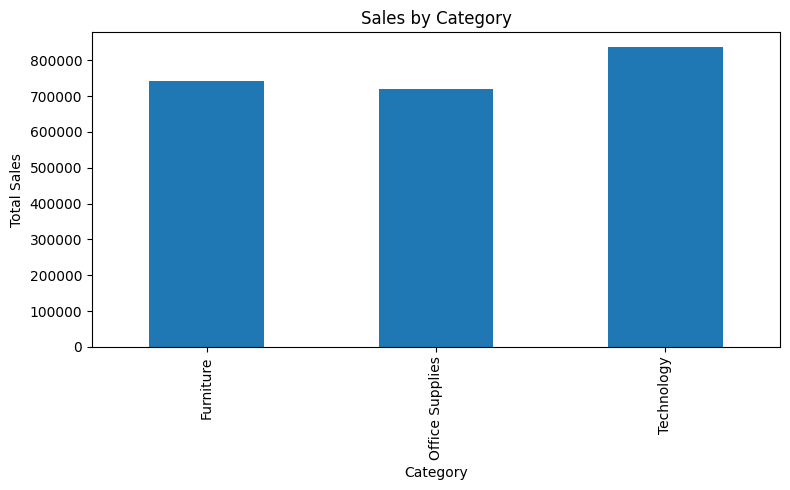

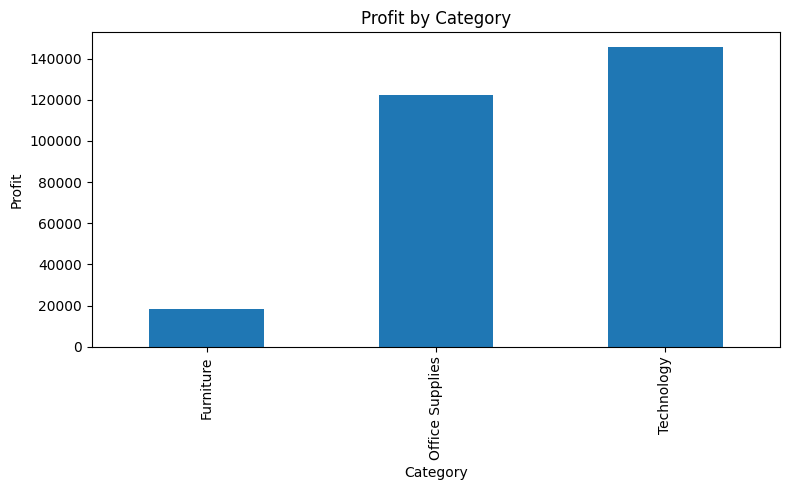

/tmp/ipykernel_4580/1645407768.py:79: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


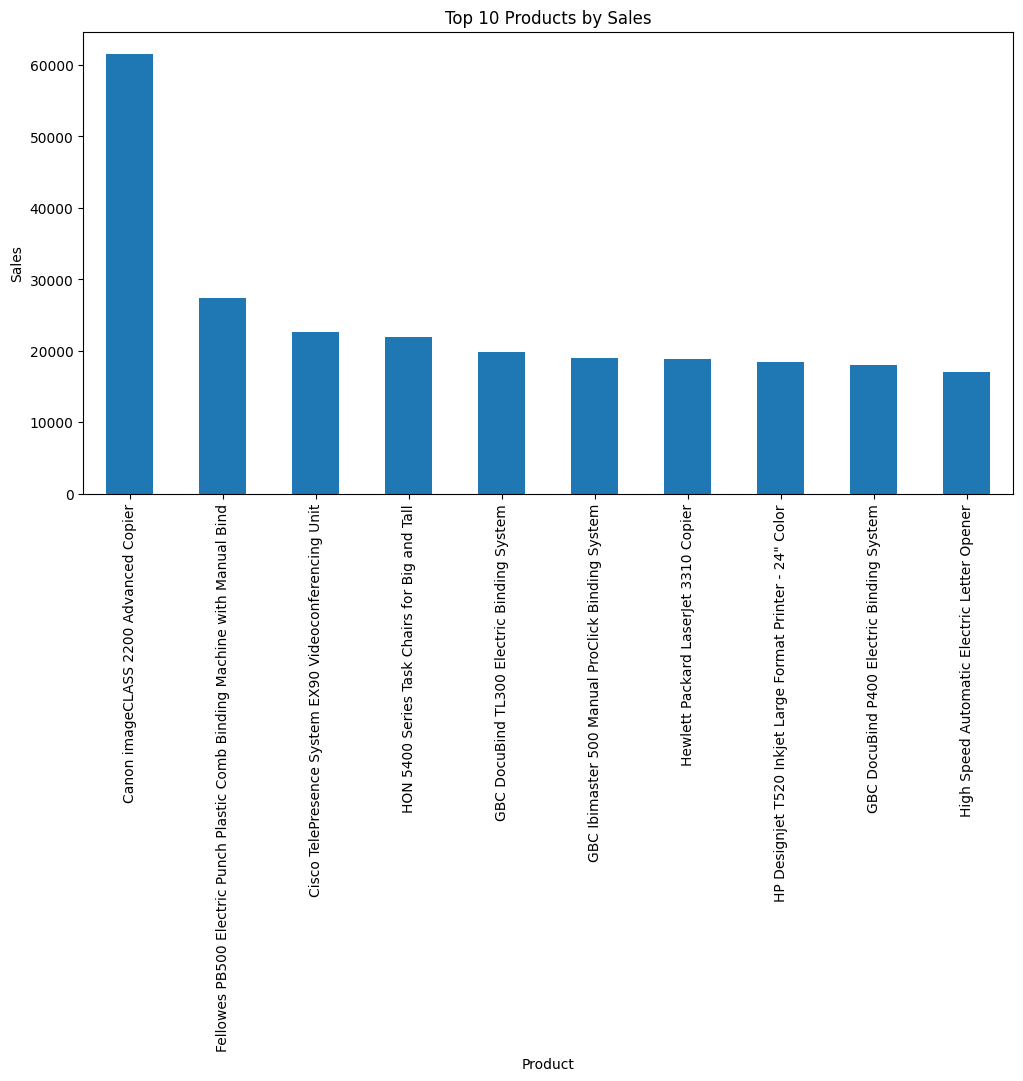

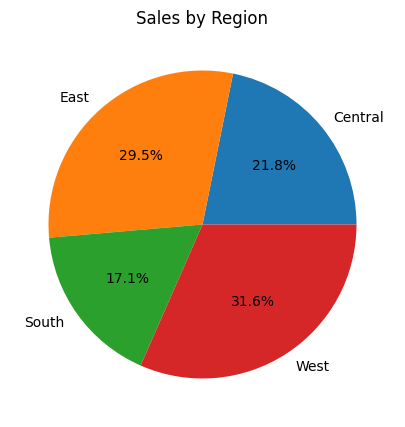

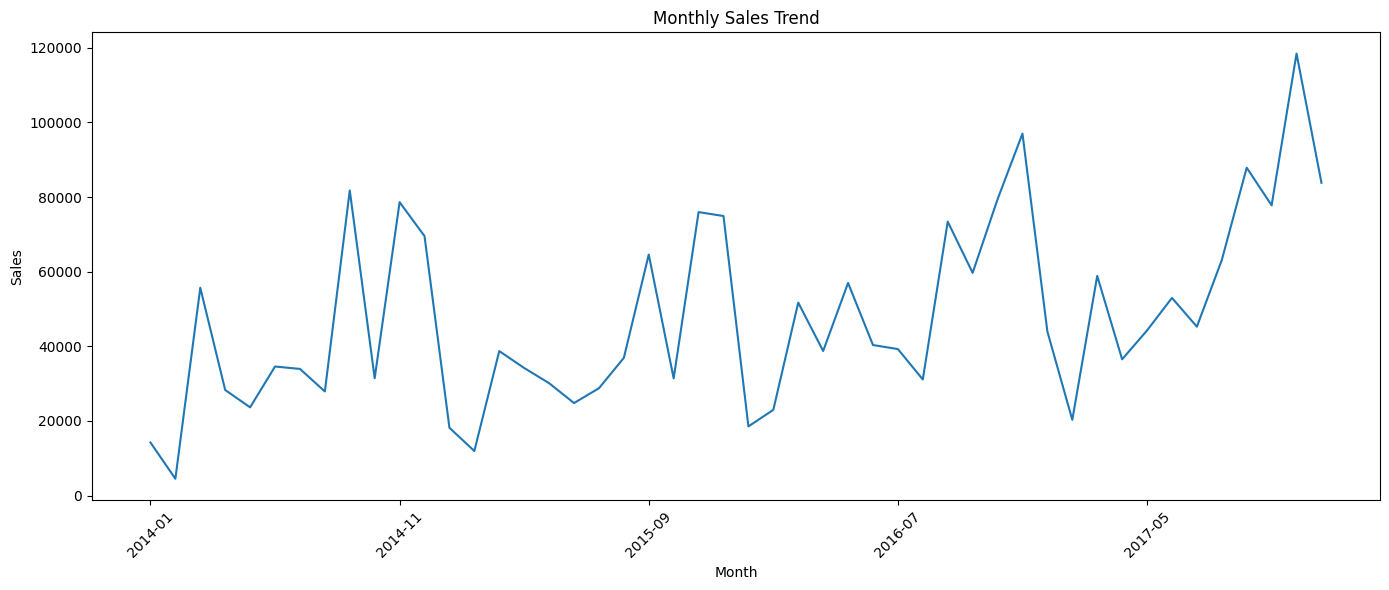


===== BUSINESS INSIGHTS =====

1. Identify the highest revenue category.
2. Identify the most profitable category.
3. Find top-performing products.
4. Analyze strongest sales regions.
5. Observe monthly sales trends.

PROJECT COMPLETED SUCCESSFULLY!


In [2]:
# =====================================
# SALES ANALYTICS DASHBOARD PROJECT
# =====================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folders
os.makedirs("charts", exist_ok=True)
os.makedirs("output", exist_ok=True)

# Load dataset
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Basic Information
print("\n===== DATASET INFO =====\n")
print(df.info())

print("\n===== FIRST 5 ROWS =====\n")
print(df.head())

# Save cleaned dataset
df.to_csv("output/cleaned_sales_data.csv", index=False)

# =====================================
# 1. SALES BY CATEGORY
# =====================================

category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.savefig("charts/sales_by_category.png")
plt.show()

# =====================================
# 2. PROFIT BY CATEGORY
# =====================================

profit_category = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))
profit_category.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()
plt.savefig("charts/profit_by_category.png")
plt.show()

# =====================================
# 3. TOP 10 PRODUCTS
# =====================================

top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("charts/top_products.png")
plt.show()

# =====================================
# 4. SALES BY REGION
# =====================================

region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))

plt.pie(
    region_sales.values,
    labels=region_sales.index,
    autopct="%1.1f%%"
)

plt.title("Sales by Region")

plt.savefig("charts/sales_by_region.png")
plt.show()

# =====================================
# 5. MONTHLY SALES TREND
# =====================================

df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("charts/monthly_sales_trend.png")
plt.show()

# =====================================
# INSIGHTS
# =====================================

print("\n===== BUSINESS INSIGHTS =====\n")

print("1. Identify the highest revenue category.")
print("2. Identify the most profitable category.")
print("3. Find top-performing products.")
print("4. Analyze strongest sales regions.")
print("5. Observe monthly sales trends.")

print("\nPROJECT COMPLETED SUCCESSFULLY!")